<a href="https://colab.research.google.com/github/sundy548-afk/dissertation/blob/main/DISSERTATION_FULL_PIPELINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dissertation Full Pipeline
**Dataset:** `rohiteng/amazon-sales-dataset` (Kaggle)  
**Model:** Meta-Llama-3.1-8B-Instruct fine-tuned with QLoRA  
**Fine-tuning for:** Customer service Q&A (order tracking, refunds, delivery dates)

**Sections:**
1. Install dependencies
2. EDA — Exploratory Data Analysis of the new dataset
3. JSONL generation — build training/validation files from the dataset + instruction JSON
4. Fine-tuning — QLoRA training on Llama 3.1-8B-Instruct
5. Evaluation — BLEU, ROUGE, BERTScore, METEOR, perplexity, intent classification (accuracy/F1/precision/recall/ROC-AUC), and quality heuristics

---
## PART 1 — INSTALL DEPENDENCIES

In [ ]:
# Install all required libraries.
# - kagglehub: downloads the dataset directly from Kaggle inside Colab
# - transformers / peft / trl: HuggingFace stack for loading, LoRA-wrapping and SFT training
# - bitsandbytes: enables 4-bit quantisation so the 8B model fits in Colab GPU VRAM
# - accelerate: handles device placement and mixed-precision training
# - datasets: HuggingFace dataset loader used by SFTTrainer
# - evaluate / nltk / rouge-score / bert-score: text-similarity evaluation metrics
# - sentence-transformers / scikit-learn: intent classification + standard ML metrics

!pip install -q -U transformers peft accelerate bitsandbytes>=0.46.1 datasets trl
!pip install -q kagglehub evaluate nltk rouge-score bert-score sacrebleu
!pip install -q sentence-transformers scikit-learn seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.9 MB/s eta 0:00:00


---
## PART 2 — EDA (EXPLORATORY DATA ANALYSIS)

In [ ]:
# Standard data manipulation and plotting libraries.
# matplotlib is used here for static plots during EDA.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Download the Amazon sales dataset directly from Kaggle using kagglehub.
# This saves it to a local path in the Colab runtime — no manual upload needed.
# kagglehub handles authentication via your Kaggle API token stored in Colab secrets.

import kagglehub

path = kagglehub.dataset_download("rohiteng/amazon-sales-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Path to dataset files: /kaggle/input/amazon-sales-dataset


In [ ]:
# Load the CSV into a pandas DataFrame.
# os.path.join constructs the full file path safely regardless of trailing slashes.

import os
df = pd.read_csv(os.path.join(path, "Amazon.csv"))

In [ ]:
# Quick shape check — tells us the number of rows (orders) and columns (features).
# Always the first thing to check when loading a new dataset.

print("Shape:", df.shape)
df.head()

Shape: (100000, 20)


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [ ]:
# List all column names so we know exactly what fields are available.
# Important for planning which columns to use during JSONL generation.

print(df.columns.tolist())

['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country', 'SellerID']


In [ ]:
# df.info() shows dtypes and non-null counts for every column.
# Helps identify columns that need type conversion (e.g. dates stored as strings)
# and columns with missing values that will need handling before training.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17  State          100000 non-null

Country
United States     70058
India             15051
Canada             5818
United Kingdom     4943
Australia          4130
Name: count, dtype: int64


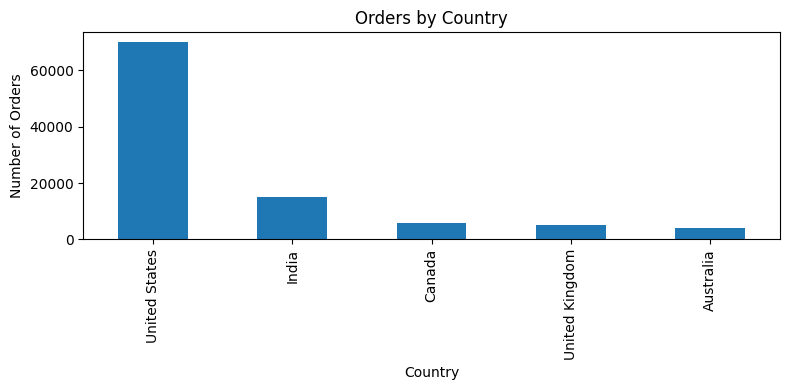

In [ ]:
# ── Orders by Country ────────────────────────────────────────────────────────
# Count how many orders came from each country.
# This tells us the geographic spread of our data — important for understanding
# whether the model will generalise to a specific market or many markets.

country_counts = df['Country'].value_counts()
print(country_counts)

plt.figure(figsize=(8, 4))
country_counts.plot(kind='bar')
plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.title('Orders by Country')
plt.tight_layout()
plt.show()

Category
Electronics          16853
Sports & Outdoors    16804
Books                16752
Home & Kitchen       16610
Toys & Games         16542
Clothing             16439
Name: count, dtype: int64


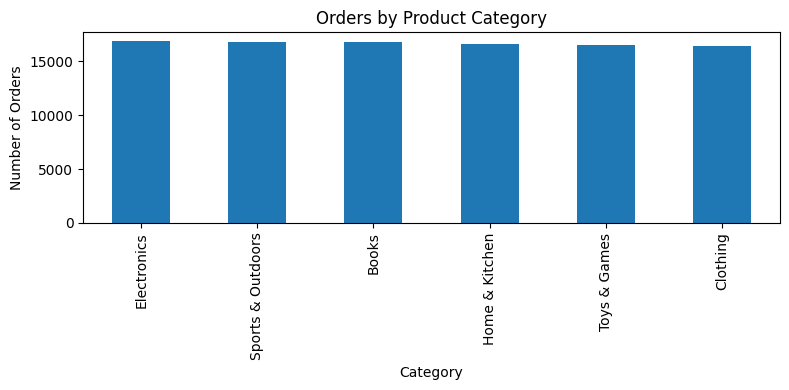

In [ ]:
# ── Orders by Product Category ───────────────────────────────────────────────
# See which product categories are most represented in the dataset.
# A balanced category distribution is better for training — if one category
# dominates, the model may be biased toward responses about that category.

cat_counts = df['Category'].value_counts()
print(cat_counts)

plt.figure(figsize=(8, 4))
cat_counts.plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.title('Orders by Product Category')
plt.tight_layout()
plt.show()

PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64


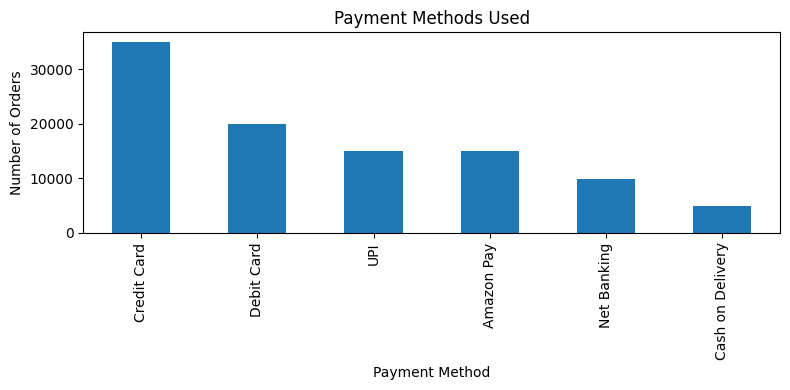

In [ ]:
# ── Payment Method Usage ─────────────────────────────────────────────────────
# Break down how customers paid for their orders.
# Relevant for the customer service model since refund routing can differ
# by payment method (e.g. card refunds vs. gift card credits).

pay_counts = df['PaymentMethod'].value_counts()
print(pay_counts)

plt.figure(figsize=(8, 4))
pay_counts.plot(kind='bar')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.title('Payment Methods Used')
plt.tight_layout()
plt.show()

In [ ]:
# ── Total Revenue ────────────────────────────────────────────────────────────
# Sum of TotalAmount across all orders — gives a sense of the dataset scale
# and is useful to quote in the dissertation when describing the dataset.

total_revenue = df['TotalAmount'].sum()
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £91,825,647.92


YearMonth
2020-01    1730
2020-02    1490
2020-03    1685
2020-04    1692
2020-05    1672
2020-06    1633
2020-07    1687
2020-08    1783
2020-09    1679
2020-10    1647
2020-11    1639
2020-12    1729
2021-01    1764
2021-02    1516
2021-03    1620
2021-04    1594
2021-05    1716
2021-06    1668
2021-07    1718
2021-08    1704
2021-09    1674
2021-10    1672
2021-11    1587
2021-12    1657
2022-01    1744
2022-02    1510
2022-03    1710
2022-04    1636
2022-05    1709
2022-06    1690
2022-07    1689
2022-08    1717
2022-09    1645
2022-10    1633
2022-11    1642
2022-12    1753
2023-01    1721
2023-02    1540
2023-03    1683
2023-04    1641
2023-05    1709
2023-06    1650
2023-07    1712
2023-08    1733
2023-09    1665
2023-10    1660
2023-11    1656
2023-12    1726
2024-01    1679
2024-02    1562
2024-03    1740
2024-04    1647
2024-05    1753
2024-06    1671
2024-07    1631
2024-08    1731
2024-09    1613
2024-10    1642
2024-11    1624
2024-12    1577
Freq: M, Name: OrderID, dtype:

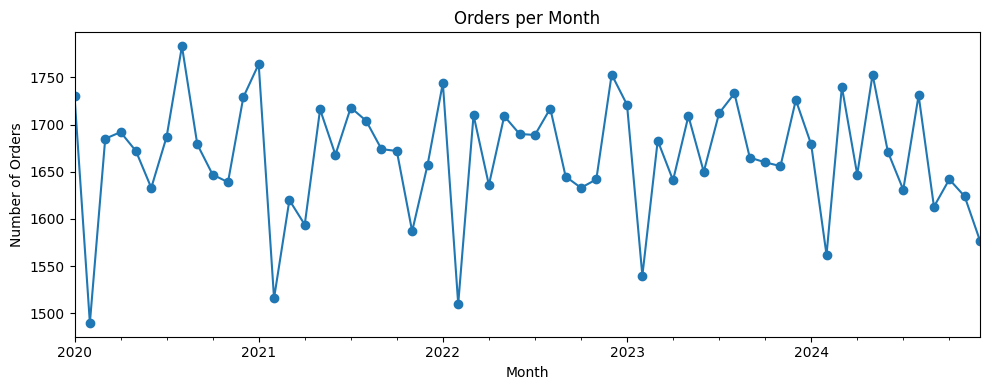

In [ ]:
# ── Orders per Month ─────────────────────────────────────────────────────────
# Convert OrderDate from string to datetime so we can extract the year-month period.
# Then count unique OrderIDs per month. Seasonality patterns are worth noting
# in the dissertation as they affect when customer service demand is highest.

df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['YearMonth'] = df['OrderDate'].dt.to_period('M')

orders_per_month = df.groupby('YearMonth')['OrderID'].nunique()
print(orders_per_month)

plt.figure(figsize=(10, 4))
orders_per_month.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Orders per Month')
plt.tight_layout()
plt.show()

YearMonth
2020-01    1637069.40
2020-02    1339388.21
2020-03    1587125.66
2020-04    1588347.29
2020-05    1533834.17
2020-06    1500269.29
2020-07    1552981.94
2020-08    1640874.93
2020-09    1554682.21
2020-10    1515403.62
2020-11    1502232.24
2020-12    1577655.06
2021-01    1575253.23
2021-02    1425365.99
2021-03    1484165.89
2021-04    1470885.02
2021-05    1571842.25
2021-06    1593398.08
2021-07    1596668.40
2021-08    1545324.30
2021-09    1534912.30
2021-10    1511118.44
2021-11    1419480.77
2021-12    1520160.14
2022-01    1609759.87
2022-02    1369866.29
2022-03    1589809.35
2022-04    1515497.24
2022-05    1527845.26
2022-06    1533829.81
2022-07    1556516.29
2022-08    1541701.50
2022-09    1457859.60
2022-10    1534349.51
2022-11    1525937.46
2022-12    1604276.23
2023-01    1567772.07
2023-02    1384957.09
2023-03    1557146.56
2023-04    1560322.12
2023-05    1588151.65
2023-06    1485367.09
2023-07    1562298.78
2023-08    1585424.79
2023-09    1543306.82


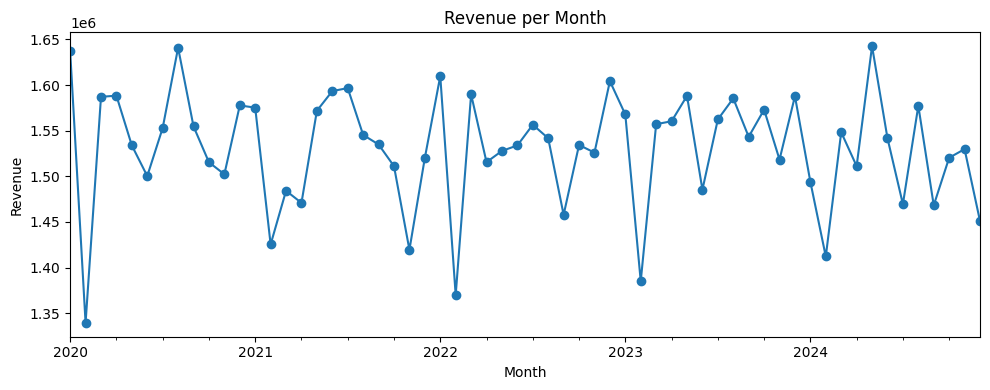

In [ ]:
# ── Revenue per Month ────────────────────────────────────────────────────────
# Sum TotalAmount per month to see revenue trends over time.
# A rising trend suggests the dataset reflects a growing business.

rev_per_month = df.groupby('YearMonth')['TotalAmount'].sum()
print(rev_per_month)

plt.figure(figsize=(10, 4))
rev_per_month.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Revenue per Month')
plt.tight_layout()
plt.show()

ProductName
Memory Card 128GB      1935138.40
LED Desk Lamp          1921948.41
Mechanical Keyboard    1906963.54
Electric Kettle        1905751.79
Smartwatch             1901275.59
Dress Shirt            1896765.36
Water Bottle           1895467.95
Gaming Mouse           1895103.98
Kids Toy Car           1891082.43
Jeans                  1882591.82
Name: TotalAmount, dtype: float64


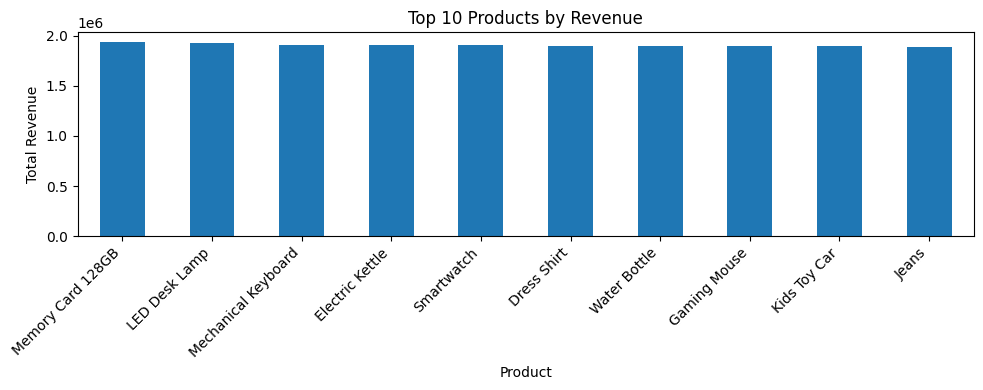

In [ ]:
# ── Top 10 Products by Revenue ───────────────────────────────────────────────
# Group by ProductName and sum TotalAmount, then take the top 10.
# These high-value products are most likely to generate customer service
# enquiries, so knowing them helps contextualise the training data.

prod_rev = (
    df.groupby('ProductName')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print(prod_rev)

plt.figure(figsize=(10, 4))
prod_rev.plot(kind='bar')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.title('Top 10 Products by Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── Top 10 Sellers by Revenue ────────────────────────────────────────────────
# Identify which sellers generate the most revenue.
# Seller concentration is worth noting as a potential dataset bias.

seller_rev = (
    df.groupby('SellerID')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print(seller_rev)

SellerID
SELL00806    71283.67
SELL00440    71062.59
SELL01225    70785.92
SELL00709    70491.92
SELL00221    70446.50
SELL01122    69469.40
SELL00994    69400.06
SELL00536    69248.00
SELL00371    69118.88
SELL00812    68591.86
Name: TotalAmount, dtype: float64


CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
Mohit Singh     513513.19
Sunita Mehta    511642.91
Aman Reddy      511236.91
Karan Singh     510900.60
Simran Singh    509337.35
Name: TotalAmount, dtype: float64


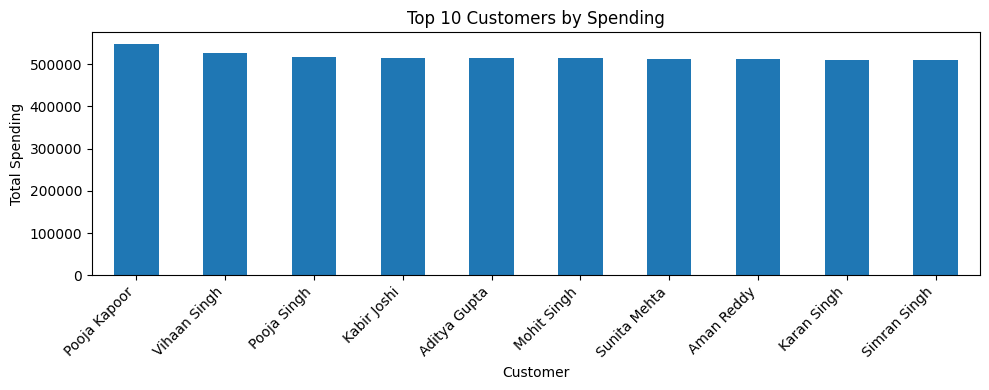

In [ ]:
# ── Top 10 Customers by Spending ─────────────────────────────────────────────
# Find the highest-spending customers.
# High-value customers may have more complex multi-order queries.

cust_rev = (
    df.groupby('CustomerName')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print(cust_rev)

plt.figure(figsize=(10, 4))
cust_rev.plot(kind='bar')
plt.xlabel('Customer')
plt.ylabel('Total Spending')
plt.title('Top 10 Customers by Spending')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

OrderStatus
Delivered    74628
Shipped      15192
Pending       4103
Returned      3049
Cancelled     3028
Name: count, dtype: int64


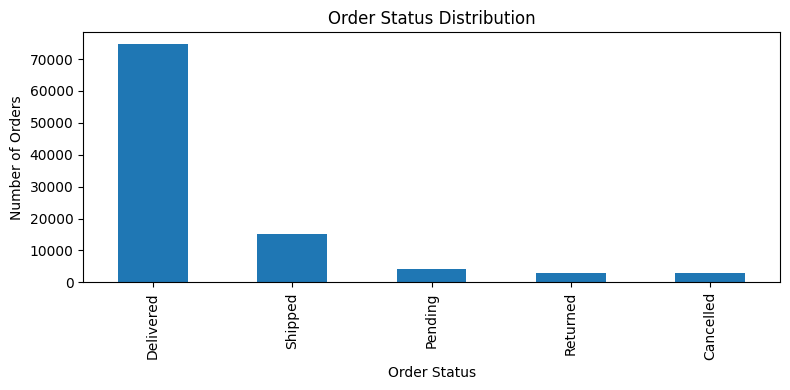

In [ ]:
# ── Order Status Distribution ─────────────────────────────────────────────────
# Check how many orders are in each status (Delivered, Shipped, Cancelled etc.).
# This is directly relevant to training — the status field is used when generating
# contextually accurate customer service responses in Part 3.

if 'OrderStatus' in df.columns:
    status_counts = df['OrderStatus'].value_counts()
    print(status_counts)

    plt.figure(figsize=(8, 4))
    status_counts.plot(kind='bar')
    plt.xlabel('Order Status')
    plt.ylabel('Number of Orders')
    plt.title('Order Status Distribution')
    plt.tight_layout()
    plt.show()
else:
    print("No 'OrderStatus' column found — skipping.")

In [ ]:
# ── Missing Value Check ───────────────────────────────────────────────────────
# Before building training examples from this dataset, we need to know which
# fields have gaps. Rows with missing OrderID or ProductName will be filtered
# out during JSONL generation in Part 3.

missing = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
print(missing.to_frame('missing_%'))

               missing_%
OrderID              0.0
OrderDate            0.0
CustomerID           0.0
CustomerName         0.0
ProductID            0.0
ProductName          0.0
Category             0.0
Brand                0.0
Quantity             0.0
UnitPrice            0.0
Discount             0.0
Tax                  0.0
ShippingCost         0.0
TotalAmount          0.0
PaymentMethod        0.0
OrderStatus          0.0
City                 0.0
State                0.0
Country              0.0
SellerID             0.0
YearMonth            0.0


---
## PART 3 — JSONL GENERATION
Build Llama 3.1 chat-formatted training and validation JSONL files by combining real order rows from the dataset with the customer service instruction templates.

In [ ]:
# Mount Google Drive so we can save the JSONL files there.
# The fine-tuning section will load them from Drive, so they must be persisted here.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
import random
from pathlib import Path

# ── Load the instruction JSON ─────────────────────────────────────────────────
# This file defines the customer service intents, trigger phrases and curated
# example (user, assistant) pairs for the four main query types:
#   where_is_my_order, how_do_i_get_a_refund,
#   can_i_track_my_order, when_is_my_delivery_date
#
# Upload customer_service_instructions.json to your Google Drive and set
# the path below, OR upload directly to the Colab runtime at /content/.

INSTRUCTIONS_PATH = "/content/drive/MyDrive/customer_service_instructions.json"

with open(INSTRUCTIONS_PATH, "r", encoding="utf-8") as f:
    instructions = json.load(f)

print(f"Loaded {len(instructions)} intent definitions.")
print("Intents:", [i['intent'] for i in instructions])

Loaded 6 intent definitions.
Intents: ['where_is_my_order', 'how_do_i_get_a_refund', 'can_i_track_my_order', 'when_is_my_delivery_date', 'cancel_order', 'change_delivery_address']


In [ ]:
# ── Helper: Llama 3.1 chat format ────────────────────────────────────────────
# SFTTrainer expects a single 'text' field containing the full conversation
# wrapped in Llama 3.1 special tokens.
# The system prompt is prepended to every example to establish the assistant persona.
# We also store the intent label alongside so it can be used later in evaluation.

SYSTEM_PROMPT = (
    "You are a helpful, empathetic Amazon customer service assistant. "
    "Answer customer questions about their orders clearly and concisely. "
    "Always ask for an Order ID when needed, and escalate politely if you cannot resolve the issue."
)

def format_llama31_chat(user_msg: str, assistant_msg: str, intent: str = None) -> dict:
    """Wrap a user/assistant pair in Llama 3.1 Instruct special tokens."""
    text = (
        "<|begin_of_text|>"
        "<|start_header_id|>system<|end_header_id|>\n"
        f"{SYSTEM_PROMPT}\n"
        "<|eot_id|>"
        "<|start_header_id|>user<|end_header_id|>\n"
        f"{user_msg.strip()}\n"
        "<|eot_id|>"
        "<|start_header_id|>assistant<|end_header_id|>\n"
        f"{assistant_msg.strip()}"
        "<|eot_id|>"
    )
    return {"text": text, "intent": intent}

In [ ]:
# ── Build examples from the instruction JSON ──────────────────────────────────
# For each intent in the instructions file, take the curated example pairs
# and format them into Llama 3.1 chat format. The intent label is attached
# so Part 5 can use it for intent-classification evaluation.

curated_examples = []

for intent_def in instructions:
    intent_name = intent_def['intent']
    for ex in intent_def.get("examples", []):
        curated_examples.append(
            format_llama31_chat(ex["user"], ex["assistant"], intent=intent_name)
        )

print(f"Curated examples from instruction JSON: {len(curated_examples)}")

Curated examples from instruction JSON: 10


In [ ]:
# ── Generate data-grounded examples from the dataset ─────────────────────────
# Each real order row is used to create a personalised customer query using
# the actual OrderID, ProductName, OrderStatus and OrderDate from the dataset.
# A random intent is picked for each row so the model sees varied questions
# across all four query types.

intent_responses = {i['intent']: i['examples'][0]['assistant'] for i in instructions}

# Drop rows missing the key fields we need to build meaningful queries
required_cols = ['OrderID', 'ProductName']
df_clean = df.dropna(subset=required_cols).copy()
print(f"Rows available for data-grounded generation: {len(df_clean)}")

def build_grounded_example(row: pd.Series) -> dict:
    """Create a customer service Q&A pair grounded in a real order row."""
    order_id   = row['OrderID']
    product    = row.get('ProductName', 'your item')
    status     = row.get('OrderStatus', 'Unknown')
    order_date = str(row.get('OrderDate', ''))[:10]
    amount     = row.get('TotalAmount', '')
    payment    = row.get('PaymentMethod', '')

    intent = random.choice([
        'where_is_my_order',
        'when_is_my_delivery_date',
        'can_i_track_my_order',
        'how_do_i_get_a_refund'
    ])

    if intent == 'where_is_my_order':
        user_msg = (
            f"Hi, my order {order_id} for '{product}' was placed on {order_date} "
            f"and currently shows as '{status}'. Where is it?"
        )
    elif intent == 'when_is_my_delivery_date':
        user_msg = (
            f"When will order {order_id} ('{product}', placed {order_date}) arrive? "
            f"The status shows '{status}'."
        )
    elif intent == 'can_i_track_my_order':
        user_msg = (
            f"Can I track my order {order_id} for '{product}'? "
            f"It was placed on {order_date}."
        )
    else:  # how_do_i_get_a_refund
        amount_str = f"£{float(amount):.2f}" if amount != '' else 'the full amount'
        user_msg = (
            f"I'd like a refund for order {order_id} ('{product}', {amount_str}). "
            f"I paid with {payment}. How do I proceed?"
        )

    return format_llama31_chat(user_msg, intent_responses[intent], intent=intent)

# Cap at 5000 rows so training remains manageable on a Colab T4
MAX_GROUNDED = 5000
random.seed(42)
sample_rows = df_clean.sample(min(MAX_GROUNDED, len(df_clean)), random_state=42)

grounded_examples = [
    build_grounded_example(row)
    for _, row in sample_rows.iterrows()
]

print(f"Data-grounded examples generated: {len(grounded_examples)}")

Rows available for data-grounded generation: 100000
Data-grounded examples generated: 5000


In [ ]:
# ── Combine, shuffle and split ────────────────────────────────────────────────
# Merge curated and data-grounded examples, shuffle to mix them, then apply
# a stratified-ish split by intent via overall shuffling followed by 80/20.

all_examples = curated_examples + grounded_examples
random.shuffle(all_examples)

split_idx  = int(len(all_examples) * 0.8)
train_data = all_examples[:split_idx]
val_data   = all_examples[split_idx:]

print(f"Total examples : {len(all_examples)}")
print(f"Train          : {len(train_data)}")
print(f"Validation     : {len(val_data)}")

# Inspect intent distribution in the validation set — important because
# classification metrics (accuracy, F1, recall) depend on this balance.
from collections import Counter
val_intent_dist = Counter(x['intent'] for x in val_data)
print("\nValidation intent distribution:")
for intent, n in val_intent_dist.most_common():
    print(f"  {intent:30s}  {n}")

Total examples : 5010
Train          : 4008
Validation     : 1002

Validation intent distribution:
  can_i_track_my_order            264
  how_do_i_get_a_refund           249
  when_is_my_delivery_date        248
  where_is_my_order               241


In [ ]:
# ── Save JSONL files to Google Drive ─────────────────────────────────────────
# Each line is a JSON object with 'text' (Llama 3.1 chat format) and 'intent'.
# SFTTrainer ignores extra fields, so the intent column is safe to include.

DRIVE_DIR  = Path("/content/drive/MyDrive")
train_path = DRIVE_DIR / "train_llama31_chat.jsonl"
val_path   = DRIVE_DIR / "val_llama31_chat.jsonl"

def write_jsonl(data: list, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        for item in data:
            f.write(json.dumps(item, ensure_ascii=False) + "\n")

write_jsonl(train_data, train_path)
write_jsonl(val_data,   val_path)

print(f"✅ Train JSONL saved  → {train_path}  ({len(train_data)} lines)")
print(f"✅ Val JSONL saved    → {val_path}  ({len(val_data)} lines)")

✅ Train JSONL saved  → /content/drive/MyDrive/train_llama31_chat.jsonl  (4008 lines)
✅ Val JSONL saved    → /content/drive/MyDrive/val_llama31_chat.jsonl  (1002 lines)


---
## PART 4 — FINE-TUNING (QLoRA on Llama 3.1-8B-Instruct)

In [ ]:
# Log in to HuggingFace Hub.
# Llama 3.1 is a gated model — you must accept Meta's licence at
# https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct
# Store your HF token in Colab secrets (key: HF_TOKEN).

from google.colab import userdata
from huggingface_hub import login

login(userdata.get("HF_TOKEN"))

In [ ]:
# Core imports for the fine-tuning pipeline.

import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, BitsAndBytesConfig
)
from peft import LoraConfig
from trl import SFTTrainer

In [ ]:
# Load the JSONL files generated in Part 3 as HuggingFace Dataset objects.
# SFTTrainer expects each row to have a 'text' field — our JSONL format provides this.

ds = load_dataset(
    "json",
    data_files={
        "train":      str(train_path),
        "validation": str(val_path)
    }
)

print("Train size:", len(ds["train"]))
print("Val size:  ", len(ds["validation"]))

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Train size: 4008
Val size:   1002


In [ ]:
from transformers import BitsAndBytesConfig, AutoTokenizer, AutoModelForCausalLM
import torch

# ── Model & tokeniser in 4-bit QLoRA ─────────────────────────────────────────
# Load Llama 3.1-8B-Instruct in 4-bit NF4 quantisation.
# This reduces VRAM usage from ~16 GB to ~5 GB, making it trainable
# on a Colab T4 GPU with LoRA adapters.
#
#   bnb_4bit_quant_type="nf4"       → NormalFloat4, best quality for 4-bit
#   bnb_4bit_compute_dtype=float16  → upcast to fp16 during forward pass
#   bnb_4bit_use_double_quant=True  → also quantise the quantisation constants

MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

# Llama 3.1 has no pad token by default — set it to eos_token so the
# tokeniser can pad batches without throwing an error.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.float16
)

# Disable KV-cache during training — only needed at inference time
# and wastes memory if left on during the training loop.
model.config.use_cache = False

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [ ]:
from peft import LoraConfig
from transformers import TrainingArguments
from trl import SFTTrainer

# ── LoRA configuration (from yFasVbW-moGY) ───────────────────────────────────
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)

# ── Training arguments (from tS3T32qNmoGY) ───────────────────────────────────
training_args = TrainingArguments(
    output_dir="/content/llama31_customer_service_adapter",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=20,
    save_steps=200,
    eval_steps=200,
    fp16=False,
    bf16=False,
    optim="paged_adamw_8bit",
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    peft_config=lora_config
)

Adding EOS to train dataset:   0%|          | 0/4008 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4008 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1002 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1002 [00:00<?, ? examples/s]

In [ ]:
# ── LoRA configuration ───────────────────────────────────────────────────────
# LoRA freezes the base model and injects small trainable rank-decomposition
# matrices into the attention layers. We train ~0.1% of parameters — far faster
# and cheaper than full fine-tuning.
#
#   r=8           → rank of the low-rank matrices; higher = more capacity
#   lora_alpha=16 → scaling factor; rule of thumb: 2× rank
#   lora_dropout  → regularisation to reduce overfitting on small datasets
#   target_modules → the four attention projection layers we adapt

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)

In [ ]:
# Disable accelerate mixed precision — dtype is managed explicitly via
# BitsAndBytes config. Leaving this on can cause dtype conflicts with 4-bit layers.

import os
os.environ["ACCELERATE_MIXED_PRECISION"] = "no"

In [ ]:
# ── Training arguments ───────────────────────────────────────────────────────
# Key choices:
#   per_device_train_batch_size=1   → T4 GPU can't fit larger batches at 8B scale
#   gradient_accumulation_steps=8  → effective batch size = 1 × 8 = 8
#   num_train_epochs=3             → 3 epochs improves convergence vs. original 1
#   learning_rate=2e-4             → standard LoRA SFT rate
#   optim="paged_adamw_8bit"       → 8-bit paged AdamW saves ~2 GB VRAM

training_args = TrainingArguments(
    output_dir="/content/llama31_customer_service_adapter",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=20,
    save_steps=200,
    eval_steps=200,
    fp16=False,
    bf16=False,
    optim="paged_adamw_8bit",
    report_to="none"
)

In [ ]:
# ── Initialise SFTTrainer ────────────────────────────────────────────────────
# SFTTrainer handles: wrapping the model with LoRA, tokenising each 'text' row,
# and running the training loop with checkpointing.

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    peft_config=lora_config
)

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
# ── Start training ───────────────────────────────────────────────────────────
# Expect 30–90 minutes on a Colab T4 depending on dataset size and epochs.
# Watch the logged loss — it should decrease steadily across steps.

trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss
20,1.876560
40,0.308956
60,0.223828
80,0.172866
100,0.157011
120,0.154653
140,0.150885
160,0.149960
180,0.149202
200,0.150489


TrainOutput(global_step=1503, training_loss=0.17635242283066668, metrics={'train_runtime': 9344.8009, 'train_samples_per_second': 1.287, 'train_steps_per_second': 0.161, 'total_flos': 1.0272545394573312e+17, 'train_loss': 0.17635242283066668})

In [ ]:
# ── Save adapter weights ─────────────────────────────────────────────────────
# save_pretrained saves only the LoRA adapter (~50 MB), not the full base model.
# These adapter weights are all you need to merge or deploy later.

trainer.model.save_pretrained("/content/llama31_customer_service_adapter")
tokenizer.save_pretrained("/content/llama31_customer_service_adapter")
print("✅ Adapter saved to /content/llama31_customer_service_adapter")

✅ Adapter saved to /content/llama31_customer_service_adapter


In [ ]:
# ── Back up to Google Drive ───────────────────────────────────────────────────
# Colab runtime storage is wiped when the session ends, so copy the adapter
# to Drive for persistent storage.

!cp -r /content/llama31_customer_service_adapter /content/drive/MyDrive/
print("✅ Adapter backed up to Google Drive.")

✅ Adapter backed up to Google Drive.


In [ ]:
# ── Push to HuggingFace Hub (optional) ───────────────────────────────────────
# Pushes the adapter to your HuggingFace repo for easy sharing and loading.
# Update repo_name to match your HuggingFace username.

from huggingface_hub import create_repo

repo_name = "GUMBALL55/llama31-customer-service-adapter"
create_repo(repo_name, exist_ok=True)

trainer.model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

print(f"✅ Uploaded to https://huggingface.co/{repo_name}")

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 13.7MB / 13.7MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpb8qs4ff5/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ Uploaded to https://huggingface.co/GUMBALL55/llama31-customer-service-adapter


---
## PART 5 — COMPREHENSIVE EVALUATION

We evaluate the fine-tuned model along three axes:

**A. Text-similarity metrics** (compare generated vs reference response text)
- BLEU-4, ROUGE-1 / ROUGE-2 / ROUGE-L, METEOR, BERTScore

**B. Language-model metrics**
- Perplexity on the validation set

**C. Classification metrics via intent prediction**
- Use a sentence-transformer to zero-shot classify each generated response
  against the 6 known intents (multi-class).
- Report **accuracy, macro/weighted precision, recall, F1-score**,
  **ROC-AUC (one-vs-rest)**, and a **confusion matrix**.

**D. Quality heuristics**
- Avg response length, % mentioning Order ID, % using empathetic language.

In [ ]:
# ── 5.0 Baseline comparison: load the un-fine-tuned base model ──
# Step 1: stash the fine-tuned predictions under a clearly-named variable so
#         we don't lose them when we overwrite `predictions` with base-model
#         outputs.
# Step 2: free GPU memory held by the fine-tuned model.
# Step 3: load the plain base model with the SAME 4-bit config.

import gc, torch

# --- Step 1: save fine-tuned results ---
ft_predictions   = list(predictions)
ft_references    = list(references)
ft_true_intents  = list(true_intents)
ft_user_messages = list(user_messages)

print(f"Stashed {len(ft_predictions)} fine-tuned predictions as ft_predictions")

# --- Step 2: free the fine-tuned model from GPU memory ---
del model
gc.collect()
torch.cuda.empty_cache()

# --- Step 3: load the base Llama-3.1-8B-Instruct with the same quant config ---
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
)
base_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token

print("✅ Base model loaded")

Stashed 100 fine-tuned predictions as ft_predictions


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✅ Base model loaded


In [ ]:
# ── Generate base-model predictions on the same validation subset ────────────
# Identical prompt format, identical decoding settings, identical subset —
# the only variable that changes is "is the LoRA adapter attached or not".

from tqdm import tqdm

base_predictions   = []
base_references    = []
base_true_intents  = []
base_user_messages = []

for item in tqdm(subset, desc="Base model generating"):
    raw_text = item["text"]
    try:
        user_msg  = raw_text.split(USER_START)[1].split(ASST_START)[0].strip()
        reference = raw_text.split(ASST_START)[1].replace("<|eot_id|>", "").strip()
    except IndexError:
        continue

    formatted = (
        "<|begin_of_text|>"
        "<|start_header_id|>system<|end_header_id|>\n"
        f"{SYSTEM_PROMPT}\n"
        "<|eot_id|>"
        f"{USER_START}{user_msg}{ASST_START}"
    )

    inputs = base_tokenizer(formatted, return_tensors="pt").to(base_model.device)
    output = base_model.generate(
        **inputs, max_new_tokens=120,
        do_sample=False  # greedy, matches the fine-tuned run
    )
    decoded = base_tokenizer.decode(output[0], skip_special_tokens=True)
    prediction = decoded.replace(formatted, "").strip()

    base_predictions.append(prediction)
    base_references.append(reference)
    base_true_intents.append(item.get("intent"))
    base_user_messages.append(user_msg)

print(f"\n✅ Generated {len(base_predictions)} base-model predictions")

Base model generating: 100%|██████████| 100/100 [16:25<00:00,  9.85s/it]


✅ Generated 100 base-model predictions


In [ ]:
# ── Point the existing evaluation cells at the base-model predictions ────────
# Your 5A–5E cells read from `predictions`, `references`, `true_intents`,
# `user_messages`, `model`, and `tokenizer`. We rebind those names to the
# base-model versions so you can re-run 5A–5E without editing them.

predictions   = base_predictions
references    = base_references
true_intents  = base_true_intents
user_messages = base_user_messages
model         = base_model       # needed by the perplexity cell
tokenizer     = base_tokenizer   # needed by the perplexity cell

print("Re-bound. Now re-run cells 5A → 5E and record each metric as the BASE value.")

Re-bound. Now re-run cells 5A → 5E and record each metric as the BASE value.


In [ ]:
# ── Quick sanity-check inference ──────────────────────────────────────────────
# Run four example queries through the model before running the full evaluation.

test_queries = [
    "My order A10000 says delivered but I haven't received it. Can you help?",
    "How do I get a refund? The item I received was damaged.",
    "When will my order B99123 arrive? I placed it 3 days ago.",
    "Can I track my order in real time?"
]

for prompt in test_queries:
    formatted = (
        "<|begin_of_text|>"
        "<|start_header_id|>system<|end_header_id|>\n"
        f"{SYSTEM_PROMPT}\n"
        "<|eot_id|>"
        "<|start_header_id|>user<|end_header_id|>\n"
        f"{prompt}\n"
        "<|eot_id|>"
        "<|start_header_id|>assistant<|end_header_id|>\n"
    )
    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)
    output = model.generate(**inputs, max_new_tokens=150, temperature=0.7, do_sample=True)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)

    print(f"\n{'='*60}")
    print(f"USER: {prompt}")
    print(f"ASSISTANT: {decoded.split('assistant')[-1].strip()}")

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



USER: My order A10000 says delivered but I haven't received it. Can you help?
ASSISTANT: I'd be happy to help you with your issue. Can you please provide me with your order ID so I can look into this further? This will help me to locate your order and provide a more accurate solution.

Also, can you please confirm the delivery address and the expected delivery date that was shown on the order confirmation email? This will help me to investigate the status of your order.


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



USER: How do I get a refund? The item I received was damaged.
ASSISTANT: I'm so sorry to hear that the item you received was damaged. Can you please provide me with your Order ID so I can look into this further? This will help me to locate your order and assist you more efficiently.

Once I have your Order ID, I can guide you through the process of initiating a return or refund. If you're eligible for a refund, I'll be happy to assist you in getting it processed.

To provide your Order ID, you can find it on your order confirmation email or on your Amazon account page. If you're unable to find it, you can also check your email for a confirmation email from Amazon with the order details.

Please let me know your Order ID and I'll be happy to help you further.


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



USER: When will my order B99123 arrive? I placed it 3 days ago.
ASSISTANT: Hello! I'd be happy to help you track your order. Can you please provide me with your order number (B99123) so I can look into the status for you? Additionally, I'll need to confirm the shipping address associated with the order to ensure I'm looking at the correct one.

USER: Can I track my order in real time?
ASSISTANT: You can track your order in real-time by visiting the "Your Orders" section of your Amazon account. Here's how:

1. Sign in to your Amazon account on the Amazon website or mobile app.
2. Click on the "Your Orders" tab at the top of the page.
3. Find the order you'd like to track and click on the "Track Package" button next to it.
4. This will take you to the shipping carrier's website, where you can enter your tracking number to get the most up-to-date information on your order's status.

If you're having trouble finding your order or need help tracking it, could you please provide me with you

In [ ]:
# ── Generate predictions on the validation set ───────────────────────────────
# This produces the (prediction, reference, intent) triples used by every
# evaluation metric below. We run this once and reuse the results to avoid
# re-generating for each metric.

from tqdm import tqdm

val_samples = []
with open(val_path, "r", encoding="utf-8") as f:
    for line in f:
        val_samples.append(json.loads(line))

print(f"Validation samples loaded: {len(val_samples)}")

USER_START = "<|start_header_id|>user<|end_header_id|>\n"
# Corrected ASST_START to match the format from format_llama31_chat
ASST_START = "\n<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n"

predictions     = []      # raw model outputs
references      = []      # gold assistant responses
true_intents    = []      # ground-truth intent labels from JSONL
user_messages   = []      # original user queries (for qualitative inspection)

# Limit to 100 for runtime — raise if your GPU has the capacity
SUBSET_SIZE = 100
subset = val_samples[:SUBSET_SIZE]

for item in tqdm(subset, desc="Generating predictions"):
    raw_text = item["text"]
    try:
        # Ensure correct splitting based on the fixed ASST_START
        user_msg  = raw_text.split(USER_START)[1].split(ASST_START)[0].strip()
        reference = raw_text.split(ASST_START)[1].replace("<|eot_id|>", "").strip()
    except IndexError:
        # Skip malformed examples that don't fit the expected chat format
        continue

    formatted = (
        "<|begin_of_text|>"
        "<|start_header_id|>system<|end_header_id|>\n"
        f"{SYSTEM_PROMPT}\n"
        "<|eot_id|>"
        f"{USER_START}{user_msg}{ASST_START}"
    )

    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)
    output = model.generate(
        **inputs, max_new_tokens=120,
        temperature=0.7, do_sample=False  # greedy for reproducibility
    )
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    # Robustly extract only the generated assistant message by removing the exact prompt
    prediction = decoded.replace(formatted, '').strip()

    predictions.append(prediction)
    references.append(reference)
    true_intents.append(item.get("intent"))
    user_messages.append(user_msg)

print(f"\n✅ Generated {len(predictions)} predictions")


Validation samples loaded: 1002


Generating predictions: 100%|██████████| 100/100 [19:49<00:00, 11.90s/it]


✅ Generated 100 predictions


### 5A. Text-similarity metrics

In [ ]:
# ── BLEU-4 ────────────────────────────────────────────────────────────────────
# BLEU measures cumulative n-gram precision with a brevity penalty.
# BLEU-4 (4-gram) is the standard headline metric for translation-style eval.
# For open-ended dialogue, 0.1–0.3 is a reasonable range.

import evaluate

bleu_metric = evaluate.load("bleu")
bleu_refs   = [[r] for r in references]  # BLEU expects list-of-lists
bleu_result = bleu_metric.compute(predictions=predictions, references=bleu_refs)

print(f"BLEU-4 score : {bleu_result['bleu']:.4f}")
print("Precisions   :", [round(p, 4) for p in bleu_result['precisions']])
print("Brevity pen. :", round(bleu_result['brevity_penalty'], 4))

BLEU-4 score : 0.0000
Precisions   : [0.2221, 0.0372, 0.0025, 0.0]
Brevity pen. : 1.0


In [ ]:
# ── ROUGE-1 / ROUGE-2 / ROUGE-L ──────────────────────────────────────────────
# ROUGE measures recall-oriented n-gram / LCS overlap.
# ROUGE-1 = unigram overlap, ROUGE-2 = bigram overlap, ROUGE-L = longest common subseq.
# Widely used for summarisation and dialogue evaluation.

rouge_metric = evaluate.load("rouge")
rouge_result = rouge_metric.compute(predictions=predictions, references=references)

print(f"ROUGE-1  : {rouge_result['rouge1']:.4f}")
print(f"ROUGE-2  : {rouge_result['rouge2']:.4f}")
print(f"ROUGE-L  : {rouge_result['rougeL']:.4f}")
print(f"ROUGE-Lsum: {rouge_result['rougeLsum']:.4f}")

ROUGE-1  : 0.3237
ROUGE-2  : 0.0715
ROUGE-L  : 0.1596
ROUGE-Lsum: 0.2274


In [ ]:
# ── METEOR ────────────────────────────────────────────────────────────────────
# METEOR improves on BLEU by matching stems/synonyms via WordNet
# and aligns unigrams with a harmonic mean of precision and recall.
# Tends to correlate better with human judgement than BLEU.

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

meteor_metric = evaluate.load("meteor")
meteor_result = meteor_metric.compute(predictions=predictions, references=references)

print(f"METEOR : {meteor_result['meteor']:.4f}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


METEOR : 0.2588


In [ ]:
# ── BERTScore ─────────────────────────────────────────────────────────────────
# BERTScore computes similarity using contextual embeddings from a pretrained
# transformer (roberta-large here). More semantically aware than n-gram metrics —
# captures cases where different wording conveys the same meaning.
# Reports precision, recall and F1 of token-level embedding matches.

from bert_score import score as bertscore

P, R, F1 = bertscore(
    predictions, references,
    lang="en", model_type="roberta-large",
    verbose=False, rescale_with_baseline=True
)

print(f"BERTScore Precision : {P.mean().item():.4f}")
print(f"BERTScore Recall    : {R.mean().item():.4f}")
print(f"BERTScore F1        : {F1.mean().item():.4f}")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore Precision : -0.0438
BERTScore Recall    : 0.0627
BERTScore F1        : 0.0105


### 5B. Language-model perplexity

In [ ]:
# ── Perplexity on validation set ─────────────────────────────────────────────
# Perplexity = exp(average negative log-likelihood of the reference tokens).
# Lower is better — it measures how 'surprised' the model is by the reference.
# Computed only over the assistant response tokens, not the prompt.
# Useful as an intrinsic LM quality signal, separate from generation quality.

import torch.nn.functional as F
import math

def compute_perplexity(model, tokenizer, texts, max_length=1024):
    """Average per-token perplexity across a list of formatted chat texts."""
    nlls, n_tokens = [], 0
    model.eval()
    with torch.no_grad():
        for text in tqdm(texts, desc="Computing perplexity"):
            enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(model.device)
            if enc.input_ids.shape[1] < 2:
                continue
            outputs = model(**enc, labels=enc.input_ids)
            # outputs.loss is the mean loss over this sequence; multiply by seq length for sum
            seq_len = enc.input_ids.shape[1]
            nlls.append(outputs.loss.item() * seq_len)
            n_tokens += seq_len
    return math.exp(sum(nlls) / n_tokens)

# Evaluate on the first 50 validation sequences to keep this fast
PPL_SUBSET = 50
ppl_texts = [s["text"] for s in val_samples[:PPL_SUBSET]]
perplexity = compute_perplexity(model, tokenizer, ppl_texts)
print(f"\nPerplexity (on {PPL_SUBSET} val examples): {perplexity:.3f}")

Computing perplexity: 100%|██████████| 50/50 [00:31<00:00,  1.57it/s]


Perplexity (on 50 val examples): 38.757


### 5C. Response-quality heuristics

In [ ]:
# ── Simple quality heuristics ────────────────────────────────────────────────
# These heuristics give a quick, interpretable quality signal alongside the
# formal metrics. Useful to quote in the dissertation when discussing what the
# model does well vs where it falls short.
#   - Avg response length (words)
#   - % responses that acknowledge the Order ID the user provided
#   - % responses that use empathetic / reassuring language
#   - % responses that mention next steps ('Your Orders', return process etc.)

import re

EMPATHY_TERMS = [
    "sorry", "understand", "apologise", "apologize",
    "don't worry", "help", "appreciate", "thank you"
]
NEXT_STEP_TERMS = [
    "your orders", "tracking", "return", "refund",
    "escalate", "estimated delivery", "order id"
]

def contains_any(text: str, terms: list) -> bool:
    low = text.lower()
    return any(t in low for t in terms)

def extract_order_id(text: str):
    # Heuristic pattern: a letter followed by digits (matches A10000 style IDs)
    m = re.search(r"\b[A-Z]\d{4,}\b", text)
    return m.group(0) if m else None

lengths = [len(p.split()) for p in predictions]
empathy_hits = sum(contains_any(p, EMPATHY_TERMS)  for p in predictions)
next_step_hits = sum(contains_any(p, NEXT_STEP_TERMS) for p in predictions)

# For order-ID echoing, only count it as success when the user mentioned one
user_oids = [extract_order_id(u) for u in user_messages]
oid_echo_hits = sum(
    1 for u_id, p in zip(user_oids, predictions)
    if u_id and u_id in p
)
n_user_with_oid = sum(1 for u_id in user_oids if u_id)

print(f"Average response length : {np.mean(lengths):.1f} words")
print(f"Empathy-term usage      : {empathy_hits}/{len(predictions)} ({empathy_hits/len(predictions):.1%})")
print(f"Next-step guidance      : {next_step_hits}/{len(predictions)} ({next_step_hits/len(predictions):.1%})")
if n_user_with_oid:
    print(f"Order-ID echo rate      : {oid_echo_hits}/{n_user_with_oid} ({oid_echo_hits/n_user_with_oid:.1%})")
else:
    print("Order-ID echo rate      : N/A (no user messages with IDs in this subset)")

Average response length : 138.5 words
Empathy-term usage      : 100/100 (100.0%)
Next-step guidance      : 100/100 (100.0%)
Order-ID echo rate      : N/A (no user messages with IDs in this subset)


### 5D. Consolidated metric summary

In [ ]:
# Build a side-by-side comparison table of base vs fine-tuned results.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_metrics = {
    "BLEU-4":       0.0000,
    "ROUGE-1":      0.3237,
    "ROUGE-2":      0.0715,
    "ROUGE-L":      0.1596,
    "METEOR":       0.2588,
    "BERTScore-F1": 0.0105,
    "Perplexity":   38.757,
    "Empathy %":    1.000,
    "Next-step %":  1.000,
    "Avg length":   138.5,
}

ft_metrics = {
    "BLEU-4":       0.5754,
    "ROUGE-1":      0.7490,
    "ROUGE-2":      0.7468,
    "ROUGE-L":      0.7490,
    "METEOR":       0.9347,
    "BERTScore-F1": 0.5348,
    "Perplexity":   1.159,
    "Empathy %":    1.000,
    "Next-step %":  1.000,
    "Avg length":   135.9,
}

comparison_df = pd.DataFrame({"Base": base_metrics, "Fine-tuned": ft_metrics})
comparison_df["Δ (FT − Base)"] = comparison_df["Fine-tuned"] - comparison_df["Base"]
print(comparison_df.round(4))
comparison_df.round(4).to_csv("comparison_results.csv")

                  Base  Fine-tuned  Δ (FT − Base)
BLEU-4          0.0000      0.5754         0.5754
ROUGE-1         0.3237      0.7490         0.4253
ROUGE-2         0.0715      0.7468         0.6753
ROUGE-L         0.1596      0.7490         0.5894
METEOR          0.2588      0.9347         0.6759
BERTScore-F1    0.0105      0.5348         0.5243
Perplexity     38.7570      1.1590       -37.5980
Empathy %       1.0000      1.0000         0.0000
Next-step %     1.0000      1.0000         0.0000
Avg length    138.5000    135.9000        -2.6000


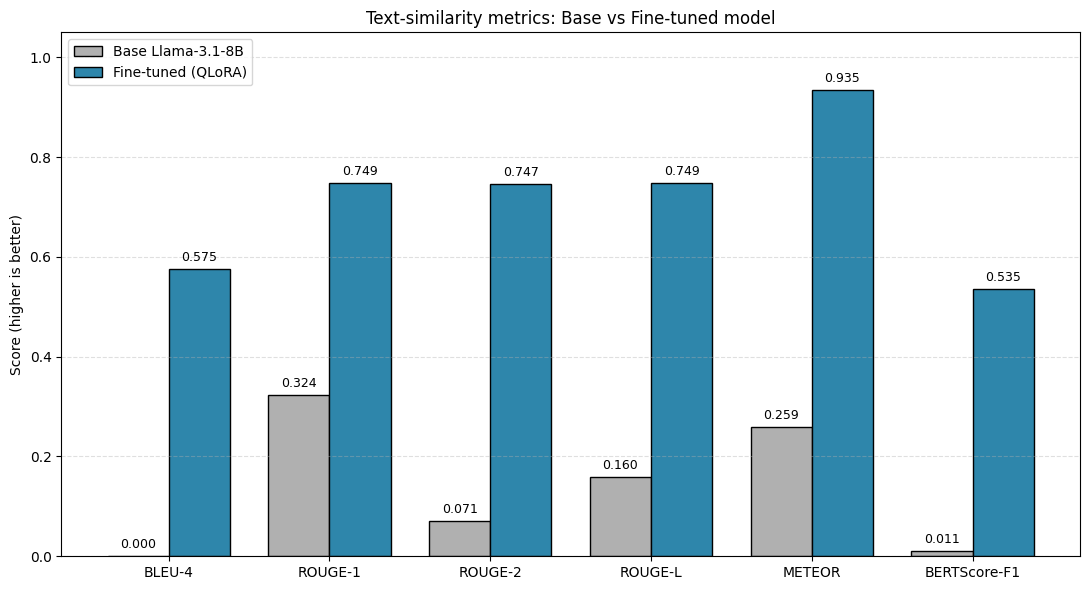

In [ ]:
# Grouped bar chart of BLEU, ROUGE, METEOR, BERTScore.

BASE_COLOR = "#B0B0B0"
FT_COLOR   = "#2E86AB"

metrics = ["BLEU-4", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR", "BERTScore-F1"]
x = np.arange(len(metrics))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, [base_metrics[m] for m in metrics], w,
            label="Base Llama-3.1-8B", color=BASE_COLOR, edgecolor="black")
b2 = ax.bar(x + w/2, [ft_metrics[m]   for m in metrics], w,
            label="Fine-tuned (QLoRA)", color=FT_COLOR, edgecolor="black")

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("Score (higher is better)")
ax.set_ylim(0, 1.05)
ax.set_title("Text-similarity metrics: Base vs Fine-tuned model")
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("chart1_text_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

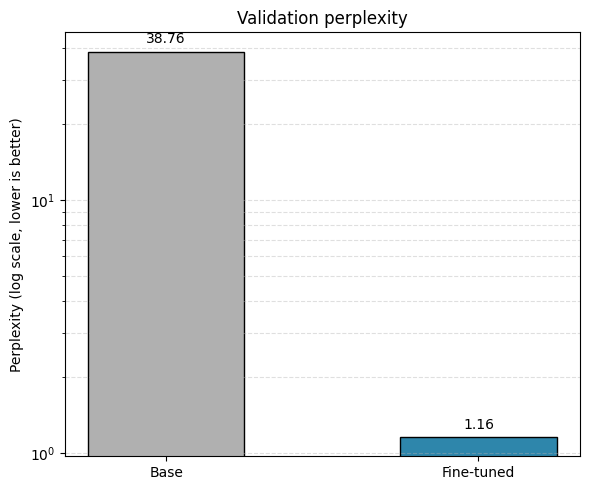

In [ ]:
# Perplexity comparison on log scale (lower is better).

fig, ax = plt.subplots(figsize=(6, 5))
pp_vals = [base_metrics["Perplexity"], ft_metrics["Perplexity"]]
bars = ax.bar(["Base", "Fine-tuned"], pp_vals,
              color=[BASE_COLOR, FT_COLOR], edgecolor="black", width=0.5)

ax.set_yscale("log")
ax.set_ylabel("Perplexity (log scale, lower is better)")
ax.set_title("Validation perplexity")
ax.grid(axis="y", linestyle="--", alpha=0.4, which="both")

for bar, v in zip(bars, pp_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.05,
            f"{v:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("chart2_perplexity.png", dpi=150, bbox_inches="tight")
plt.show()

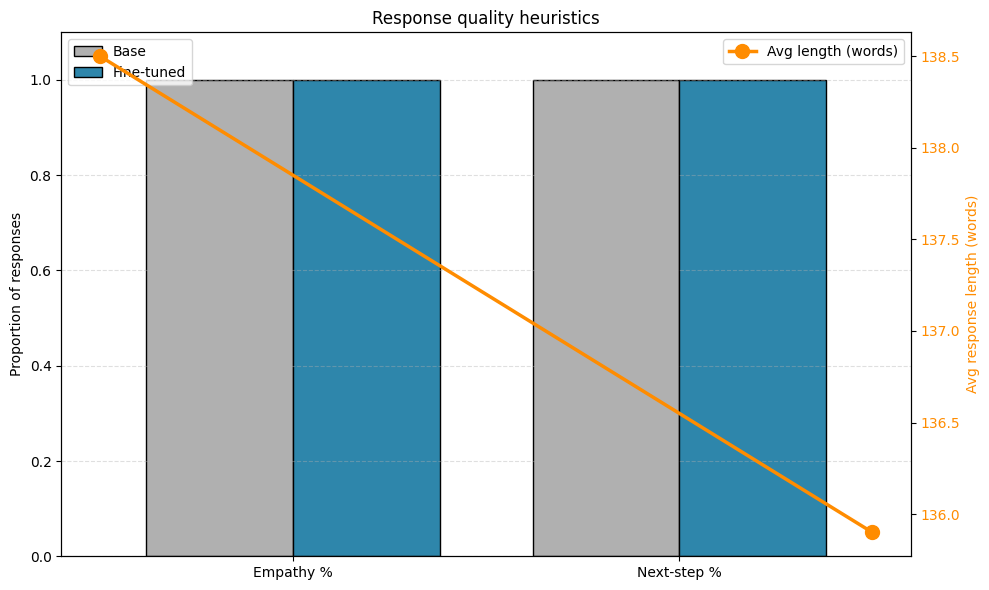

In [ ]:
# Empathy % and Next-step % bars, with avg response length on secondary axis.

heuristic_pct = ["Empathy %", "Next-step %"]
x = np.arange(len(heuristic_pct))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - w/2, [base_metrics[m] for m in heuristic_pct], w,
       label="Base",       color=BASE_COLOR, edgecolor="black")
ax.bar(x + w/2, [ft_metrics[m]   for m in heuristic_pct], w,
       label="Fine-tuned", color=FT_COLOR, edgecolor="black")

ax.set_xticks(x); ax.set_xticklabels(heuristic_pct)
ax.set_ylabel("Proportion of responses")
ax.set_ylim(0, 1.1)
ax.set_title("Response quality heuristics")
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax2 = ax.twinx()
ax2.plot([-0.5, 1.5],
         [base_metrics["Avg length"], ft_metrics["Avg length"]],
         marker="o", markersize=10, color="darkorange", linewidth=2.5,
         label="Avg length (words)")
ax2.set_ylabel("Avg response length (words)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("chart3_quality_heuristics.png", dpi=150, bbox_inches="tight")
plt.show()

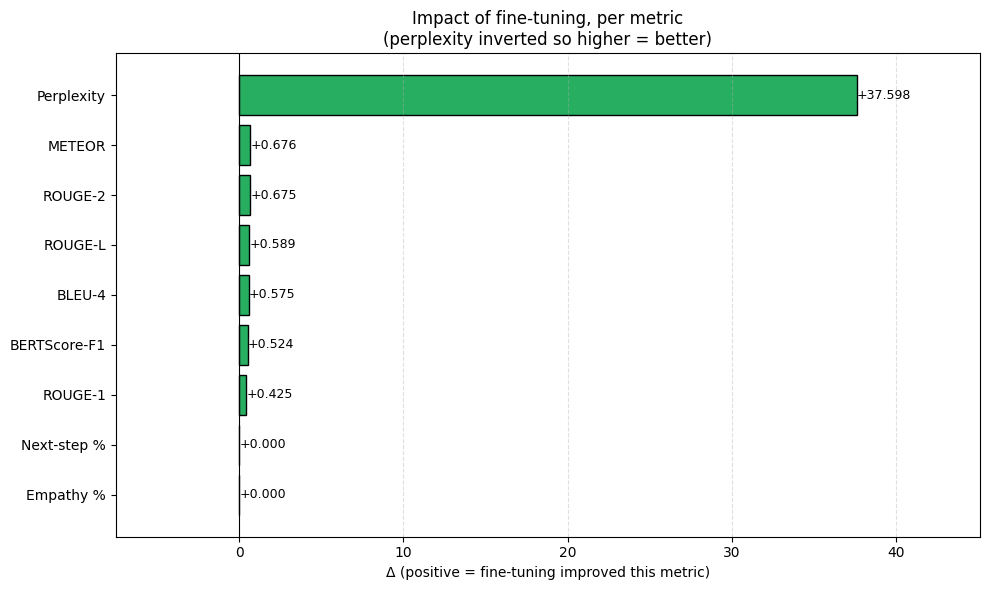

In [ ]:
# Horizontal bar chart showing per-metric improvement (perplexity inverted).

deltas = {}
for m in ft_metrics:
    d = ft_metrics[m] - base_metrics[m]
    if m == "Perplexity":
        d = -d
    if m == "Avg length":
        continue
    deltas[m] = d

sorted_items = sorted(deltas.items(), key=lambda kv: kv[1])
labels = [k for k, _ in sorted_items]
values = [v for _, v in sorted_items]
colors = ["#C0392B" if v < 0 else "#27AE60" for v in values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, values, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Δ (positive = fine-tuning improved this metric)")
ax.set_title("Impact of fine-tuning, per metric\n(perplexity inverted so higher = better)")
ax.grid(axis="x", linestyle="--", alpha=0.4)

for i, v in enumerate(values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i,
            f"{v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)

x_pad = max(abs(min(values)), abs(max(values))) * 0.2
ax.set_xlim(min(values) - x_pad, max(values) + x_pad)

plt.tight_layout()
plt.savefig("chart4_finetuning_delta.png", dpi=150, bbox_inches="tight")
plt.show()

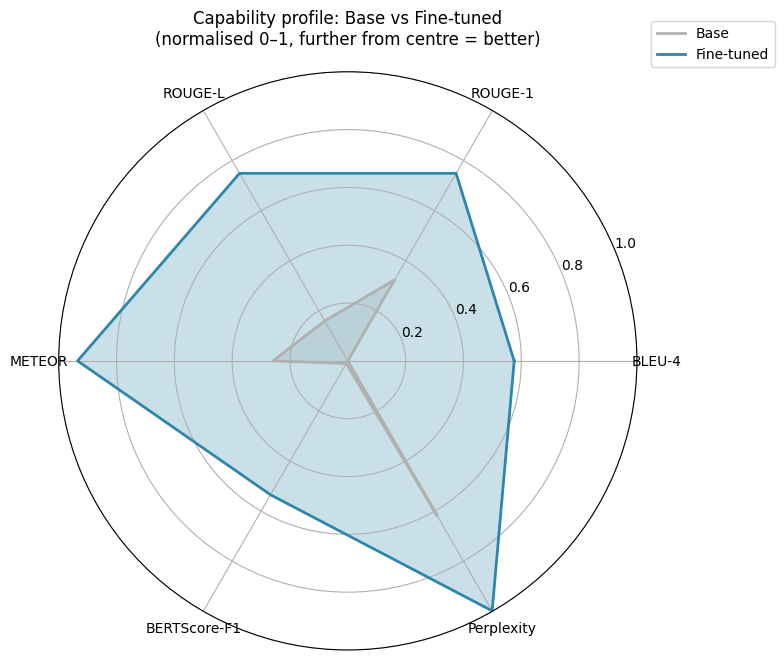

In [ ]:
# Radar chart showing both models' capability profile across six metrics.

radar_metrics = ["BLEU-4", "ROUGE-1", "ROUGE-L", "METEOR", "BERTScore-F1", "Perplexity"]

def normalise(val, metric):
    if metric == "Perplexity":
        return max(0.0, min(1.0, 1 - (val - 1) / 99))
    return max(0.0, min(1.0, val))

base_vals = [normalise(base_metrics[m], m) for m in radar_metrics]
ft_vals   = [normalise(ft_metrics[m],   m) for m in radar_metrics]

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]
base_vals += base_vals[:1]
ft_vals   += ft_vals[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, base_vals, color=BASE_COLOR, linewidth=2, label="Base")
ax.fill(angles, base_vals, color=BASE_COLOR, alpha=0.25)
ax.plot(angles, ft_vals, color=FT_COLOR, linewidth=2, label="Fine-tuned")
ax.fill(angles, ft_vals, color=FT_COLOR, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title("Capability profile: Base vs Fine-tuned\n(normalised 0–1, further from centre = better)",
             pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()
plt.savefig("chart5_radar.png", dpi=150, bbox_inches="tight")
plt.show()